# Pandas - 데이터 수집과 그룹 연산 실습

## 실습 목표

이 노트북은 **Pandas - 데이터 수집과 그룹 연산** 강의 흐름에 맞추어, 실제 데이터와 직접 생성한 거래 데이터를 함께 사용해 다음 내용을 실습합니다.

- 여러 원천 데이터 수집: CSV, Excel/JSON 유사 데이터, 직접 생성 데이터
- `groupby`의 분리-적용-결합(split-apply-combine) 구조 이해
- Series / DataFrame 기준 그룹화
- 단일 키, 복수 키, 외부 Series/함수 기반 그룹화
- `agg`, 사용자 정의 집계 함수, named aggregation
- `transform`, `apply`, `filter`
- 그룹별 결측값 대체와 비율 계산
- `pivot_table`, `crosstab`
- 시계열 그룹 연산과 리샘플링
- 그룹 연산 결과 시각화

> 사용 데이터: `iris.data`, `cancer.csv`, `stock_px.csv`, `CCTV_result.csv`, 그리고 직접 생성한 거래 데이터

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# 데이터 경로 설정
DATA_DIR = Path('/mnt/data') if Path('/mnt/data').exists() else Path('./data')
OUTPUT_DIR = DATA_DIR / 'groupby_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# 그래프 기본 설정
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.unicode_minus'] = False

# 가능한 경우 한글 폰트 설정
try:
    import matplotlib.font_manager as fm
    available_fonts = {f.name for f in fm.fontManager.ttflist}
    for font in ['NanumGothic', 'Malgun Gothic', 'AppleGothic', 'DejaVu Sans']:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            break
except Exception:
    pass

print('DATA_DIR =', DATA_DIR)
print('OUTPUT_DIR =', OUTPUT_DIR)

DATA_DIR = data
OUTPUT_DIR = data\groupby_outputs


## 1. 데이터 수집: 여러 원천 데이터 불러오기

데이터 수집은 단순히 웹에서 가져오는 것만 의미하지 않습니다. 실무에서는 CSV, Excel, JSON, DB, API 응답, 로그 등 다양한 원천을 읽어 하나의 분석 가능한 DataFrame으로 정리합니다.

이번 실습에서는 다음 데이터를 불러옵니다.

| 데이터 | 파일 | 활용 목적 |
|---|---|---|
| 붓꽃 데이터 | `iris.data` | 품종별 그룹 통계 |
| 유방암 진단 데이터 | `cancer.csv` | 진단 유형별 그룹 통계 |
| 주가 데이터 | `stock_px.csv` | 시계열 그룹 연산 |
| 서울 CCTV 결과 | `CCTV_result.csv` | 구간화 후 그룹 요약 |

In [2]:
def read_csv_safe(filename, **kwargs):
    path = DATA_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f'{path} 파일이 없습니다. 노트북과 같은 폴더 또는 /mnt/data에 배치하세요.')
    return pd.read_csv(path, **kwargs)

iris_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris = read_csv_safe('iris.data', header=None, names=iris_cols)

cancer = read_csv_safe('cancer.csv')

stock = read_csv_safe('stock_px.csv')
stock = stock.rename(columns={'Unnamed: 0': 'date'})
stock['date'] = pd.to_datetime(stock['date'])

cctv = read_csv_safe('CCTV_result.csv')

print('iris:', iris.shape)
print('cancer:', cancer.shape)
print('stock:', stock.shape)
print('cctv:', cctv.shape)

iris: (150, 5)
cancer: (569, 31)
stock: (2214, 5)
cctv: (25, 11)


In [3]:
# 각 데이터의 첫 부분 확인
for name, df in {'iris': iris, 'cancer': cancer, 'stock': stock, 'cctv': cctv}.items():
    print(f'\n[{name}]')
    display(df.head(3))


[iris]


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.100,3.500,1.400,0.200,Iris-setosa
1,4.900,3.000,1.400,0.200,Iris-setosa
2,4.700,3.200,1.300,0.200,Iris-setosa



[cancer]


,type,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,malignant,17.990,10.380,122.800,"1,001.000",0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,"2,019.000",0.162,0.666,0.712,0.265,0.460,0.119
1,malignant,20.570,17.770,132.900,"1,326.000",0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,"1,956.000",0.124,0.187,0.242,0.186,0.275,0.089
2,malignant,19.690,21.250,130.000,"1,203.000",0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,"1,709.000",0.144,0.424,0.450,0.243,0.361,0.088



[stock]


,date,AAPL,MSFT,XOM,SPX
0,2003-01-02,7.400,21.110,29.220,909.030
1,2003-01-03,7.450,21.140,29.240,908.590
2,2003-01-06,7.450,21.520,29.960,929.010



[cctv]


,구별,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율,CCTV비율,오차
0,강남구,2780,150.619,"570,500.000","565,550.000","4,950.000","63,167.000",0.868,11.072,0.487,"1,388.055"
1,강동구,773,166.491,"453,233.000","449,019.000","4,214.000","54,622.000",0.930,12.052,0.171,465.423
2,강북구,748,125.203,"330,192.000","326,686.000","3,506.000","54,813.000",1.062,16.600,0.227,329.342


### 1-1. 수집 데이터 메타정보 만들기

여러 원천을 다룰 때는 데이터의 출처, 행/열 수, 주요 키, 시간 컬럼 등을 함께 기록해 두는 습관이 중요합니다.

In [4]:
metadata = pd.DataFrame([
    {'dataset': 'iris', 'source': 'iris.data', 'rows': len(iris), 'columns': iris.shape[1], 'main_key': 'species', 'time_column': None},
    {'dataset': 'cancer', 'source': 'cancer.csv', 'rows': len(cancer), 'columns': cancer.shape[1], 'main_key': 'type', 'time_column': None},
    {'dataset': 'stock', 'source': 'stock_px.csv', 'rows': len(stock), 'columns': stock.shape[1], 'main_key': 'ticker', 'time_column': 'date'},
    {'dataset': 'cctv', 'source': 'CCTV_result.csv', 'rows': len(cctv), 'columns': cctv.shape[1], 'main_key': '구별', 'time_column': None},
])
metadata

,dataset,source,rows,columns,main_key,time_column
0,iris,iris.data,150,5,species,None
1,cancer,cancer.csv,569,31,type,None
2,stock,stock_px.csv,2214,5,ticker,date
3,cctv,CCTV_result.csv,25,11,구별,None


## 2. 직접 생성한 거래 데이터 수집 시나리오

그룹 연산을 설명하기 가장 좋은 데이터는 **거래/주문 데이터**입니다.  
아래에서는 월별로 수집된 주문 파일 3개가 있다고 가정하고, 이를 하나의 DataFrame으로 합칩니다.

In [5]:
np.random.seed(42)

n = 180
order_dates = pd.date_range('2024-01-01', '2024-03-31', freq='D')

sales_raw = pd.DataFrame({
    'order_id': [f'ORD-{i:04d}' for i in range(1, n + 1)],
    'order_date': np.random.choice(order_dates, size=n),
    'region': np.random.choice(['수도권', '충청', '영남', '호남'], size=n, p=[0.45, 0.15, 0.25, 0.15]),
    'channel': np.random.choice(['온라인', '매장', '파트너'], size=n, p=[0.55, 0.30, 0.15]),
    'product': np.random.choice(['노트북', '태블릿', '모니터', '키보드', '마우스'], size=n, p=[0.22, 0.18, 0.23, 0.20, 0.17]),
    'customer_id': np.random.choice([f'C{i:03d}' for i in range(1, 61)], size=n),
    'quantity': np.random.randint(1, 6, size=n),
    'unit_price': np.random.choice([12000, 25000, 45000, 180000, 950000, 1250000], size=n, p=[0.18, 0.22, 0.20, 0.18, 0.12, 0.10]),
    'discount_rate': np.random.choice([0.0, 0.05, 0.10, 0.15, np.nan], size=n, p=[0.35, 0.25, 0.18, 0.12, 0.10]),
    'shipping_fee': np.random.choice([0, 2500, 3000, 5000, np.nan], size=n, p=[0.25, 0.25, 0.25, 0.15, 0.10]),
    'is_returned': np.random.choice([0, 1], size=n, p=[0.88, 0.12]),
    'rating': np.random.choice([1, 2, 3, 4, 5, np.nan], size=n, p=[0.05, 0.10, 0.20, 0.35, 0.20, 0.10]),
})

sales_raw['order_date'] = pd.to_datetime(sales_raw['order_date'])
sales_raw['order_month'] = sales_raw['order_date'].dt.to_period('M').astype(str)
sales_raw['gross_amount'] = sales_raw['quantity'] * sales_raw['unit_price']
sales_raw['net_amount'] = sales_raw['gross_amount'] * (1 - sales_raw['discount_rate'].fillna(0)) + sales_raw['shipping_fee'].fillna(0)

sales_raw.head()

,order_id,order_date,region,channel,product,customer_id,quantity,unit_price,discount_rate,shipping_fee,is_returned,rating,order_month,gross_amount,net_amount
0,ORD-0001,2024-02-21,수도권,파트너,마우스,C006,3,45000,NaN,"3,000.000",0,5.000,2024-02,135000,"138,000.000"
1,ORD-0002,2024-01-15,영남,온라인,노트북,C006,1,25000,0.100,"5,000.000",0,3.000,2024-01,25000,"27,500.000"
2,ORD-0003,2024-03-12,호남,온라인,태블릿,C055,4,180000,0.100,"5,000.000",0,4.000,2024-03,720000,"653,000.000"
3,ORD-0004,2024-03-01,수도권,매장,마우스,C048,2,45000,0.050,0.000,0,5.000,2024-03,90000,"85,500.000"
4,ORD-0005,2024-01-21,충청,온라인,마우스,C004,2,45000,0.000,"2,500.000",0,NaN,2024-01,90000,"92,500.000"


In [6]:
# 월별 수집 파일처럼 분리해 저장한 뒤 다시 읽어오기
monthly_files = []
for month, chunk in sales_raw.groupby('order_month'):
    file_path = OUTPUT_DIR / f'sales_{month}.csv'
    chunk.to_csv(file_path, index=False, encoding='utf-8-sig')
    monthly_files.append(file_path)

monthly_files

[WindowsPath('data/groupby_outputs/sales_2024-01.csv'),
 WindowsPath('data/groupby_outputs/sales_2024-02.csv'),
 WindowsPath('data/groupby_outputs/sales_2024-03.csv')]

In [7]:
# 여러 CSV를 수집하여 하나의 DataFrame으로 결합
collected_sales = []
for file_path in monthly_files:
    tmp = pd.read_csv(file_path, parse_dates=['order_date'])
    tmp['collected_file'] = file_path.name
    collected_sales.append(tmp)

sales = pd.concat(collected_sales, ignore_index=True)

print(sales.shape)
sales.head()

(180, 16)


,order_id,order_date,region,channel,product,customer_id,quantity,unit_price,discount_rate,shipping_fee,is_returned,rating,order_month,gross_amount,net_amount,collected_file
0,ORD-0002,2024-01-15,영남,온라인,노트북,C006,1,25000,0.100,"5,000.000",0,3.000,2024-01,25000,"27,500.000",sales_2024-01.csv
1,ORD-0005,2024-01-21,충청,온라인,마우스,C004,2,45000,0.000,"2,500.000",0,NaN,2024-01,90000,"92,500.000",sales_2024-01.csv
2,ORD-0011,2024-01-24,수도권,매장,태블릿,C055,4,950000,0.000,"3,000.000",0,4.000,2024-01,3800000,"3,803,000.000",sales_2024-01.csv
3,ORD-0012,2024-01-03,충청,온라인,모니터,C009,5,45000,NaN,"3,000.000",0,5.000,2024-01,225000,"228,000.000",sales_2024-01.csv
4,ORD-0013,2024-01-22,영남,온라인,노트북,C055,4,950000,0.150,"3,000.000",0,4.000,2024-01,3800000,"3,233,000.000",sales_2024-01.csv


### 2-1. JSON/API 응답 형태의 보조 데이터 수집

실무에서는 API 응답처럼 JSON 구조로 들어온 데이터를 DataFrame으로 변환한 뒤 기존 데이터와 함께 사용합니다.

In [8]:
# API 응답이라고 가정한 JSON 유사 데이터
campaign_response = [
    {'channel': '온라인', 'campaign': '검색광고', 'monthly_budget': 8_000_000},
    {'channel': '매장', 'campaign': '지역프로모션', 'monthly_budget': 3_500_000},
    {'channel': '파트너', 'campaign': '제휴마케팅', 'monthly_budget': 2_400_000},
]

campaign = pd.DataFrame(campaign_response)
campaign

,channel,campaign,monthly_budget
0,온라인,검색광고,8000000
1,매장,지역프로모션,3500000
2,파트너,제휴마케팅,2400000


In [9]:
# 보조 데이터와 결합: 채널별 캠페인 정보를 주문 데이터에 붙이기
sales = sales.merge(campaign, on='channel', how='left')
sales[['order_id', 'order_date', 'region', 'channel', 'campaign', 'product', 'net_amount']].head()

,order_id,order_date,region,channel,campaign,product,net_amount
0,ORD-0002,2024-01-15,영남,온라인,검색광고,노트북,"27,500.000"
1,ORD-0005,2024-01-21,충청,온라인,검색광고,마우스,"92,500.000"
2,ORD-0011,2024-01-24,수도권,매장,지역프로모션,태블릿,"3,803,000.000"
3,ORD-0012,2024-01-03,충청,온라인,검색광고,모니터,"228,000.000"
4,ORD-0013,2024-01-22,영남,온라인,검색광고,노트북,"3,233,000.000"


## 3. GroupBy 메커닉: split-apply-combine

`groupby`는 다음 세 단계로 이해할 수 있습니다.

1. **Split**: 기준 키에 따라 데이터를 그룹으로 나눔
2. **Apply**: 각 그룹에 함수 적용
3. **Combine**: 결과를 다시 하나의 객체로 결합

In [10]:
mini = pd.DataFrame({
    'key': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C'],
    'data': [0, 5, 10, 5, 10, 15, 10, 15, 20]
})
mini

,key,data
0,A,0
1,B,5
2,C,10
3,A,5
4,B,10
5,C,15
6,A,10
7,B,15
8,C,20


In [11]:
# key별 합계: split -> sum -> combine
mini.groupby('key')['data'].sum()

key
A    15
B    30
C    45
Name: data, dtype: int64

In [12]:
# GroupBy 객체는 실제 계산 전까지는 '그룹화 계획'에 가깝습니다.
grouped = mini.groupby('key')
print(type(grouped))
print('그룹 이름:', grouped.groups.keys())
print('A 그룹의 행 위치:', grouped.groups['A'])

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>
그룹 이름: dict_keys(['A', 'B', 'C'])
A 그룹의 행 위치: Index([0, 3, 6], dtype='int64')


In [13]:
# 그룹 순회하기
for group_name, group_df in mini.groupby('key'):
    print('\n그룹:', group_name)
    display(group_df)


그룹: A


,key,data
0,A,0
3,A,5
6,A,10



그룹: B


,key,data
1,B,5
4,B,10
7,B,15



그룹: C


,key,data
2,C,10
5,C,15
8,C,20


## 4. Series를 기준으로 그룹화하기

Series 하나를 선택한 뒤 다른 Series를 기준으로 그룹화할 수 있습니다.  
예: iris 데이터에서 `sepal_length`를 `species` 기준으로 그룹화합니다.

In [14]:
sepal_by_species = iris['sepal_length'].groupby(iris['species'])
sepal_by_species.mean()

species
Iris-setosa       5.006
Iris-versicolor   5.936
Iris-virginica    6.588
Name: sepal_length, dtype: float64

In [15]:
# 여러 통계량을 한 번에 확인
sepal_by_species.agg(['count', 'mean', 'median', 'std', 'min', 'max'])

,count,mean,median,std,min,max
species,,,,,,
Iris-setosa,50,5.006,5.000,0.352,4.300,5.800
Iris-versicolor,50,5.936,5.900,0.516,4.900,7.000
Iris-virginica,50,6.588,6.500,0.636,4.900,7.900


## 5. DataFrame 전체에 groupby 적용하기

DataFrame에 `groupby`를 적용하면 숫자형 컬럼에 대해 그룹별 통계를 계산할 수 있습니다.

In [16]:
# iris 품종별 평균
iris.groupby('species').mean(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [17]:
# cancer 데이터: 진단 유형별 평균
cancer.groupby('type').mean(numeric_only=True).iloc[:, :8]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points
type,,,,,,,,
benign,12.147,17.915,78.075,462.790,0.092,0.080,0.046,0.026
malignant,17.463,21.605,115.365,978.376,0.103,0.145,0.161,0.088


In [18]:
# describe는 그룹별 기본 통계량을 폭넓게 보여줍니다.
cancer.groupby('type')['mean radius'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
benign,357.000,12.147,1.781,6.981,11.080,12.200,13.370,17.850
malignant,212.000,17.463,3.204,10.950,15.075,17.325,19.590,28.110


## 6. 복수 키 기준 그룹화

여러 개의 키를 사용하면 더 세밀한 요약이 가능합니다.  
예: `region`과 `product`를 동시에 기준으로 매출을 요약합니다.

In [19]:
# 지역 x 상품별 매출 요약
region_product_summary = sales.groupby(['region', 'product']).agg(
    orders=('order_id', 'count'),
    customers=('customer_id', 'nunique'),
    quantity_sum=('quantity', 'sum'),
    net_amount_sum=('net_amount', 'sum'),
    net_amount_mean=('net_amount', 'mean'),
    return_rate=('is_returned', 'mean')
).sort_values('net_amount_sum', ascending=False)

region_product_summary.head(10)

orders  customers  quantity_sum  net_amount_sum  net_amount_mean  return_rate
region product                                                                               
수도권    노트북          19         17            55  23,642,950.000    1,244,365.789        0.000
       모니터          17         14            63  23,245,850.000    1,367,402.941        0.176
영남     노트북          10          9            27  13,733,500.000    1,373,350.000        0.100
충청     모니터           8          8            23  12,198,200.000    1,524,775.000        0.000
수도권    마우스          16         14            51  11,577,050.000      723,565.625        0.188
영남     키보드           8          8            22  11,301,000.000    1,412,625.000        0.125
       태블릿          13         11            36  10,336,650.000      795,126.923        0.077
       마우스           6          6            17   9,603,250.000    1,600,541.667        0.000
호남     노트북          10         10            28   8,787,550.000      878,755.000        0.100
수도권    태블릿          14         12            36   8,522,500.000      608,750.000        0.071

In [20]:
# MultiIndex 결과를 일반 컬럼으로 되돌리기
region_product_summary_reset = region_product_summary.reset_index()
region_product_summary_reset.head()

,region,product,orders,customers,quantity_sum,net_amount_sum,net_amount_mean,return_rate
0,수도권,노트북,19,17,55,"23,642,950.000","1,244,365.789",0.000
1,수도권,모니터,17,14,63,"23,245,850.000","1,367,402.941",0.176
2,영남,노트북,10,9,27,"13,733,500.000","1,373,350.000",0.100
3,충청,모니터,8,8,23,"12,198,200.000","1,524,775.000",0.000
4,수도권,마우스,16,14,51,"11,577,050.000","723,565.625",0.188


In [21]:
# as_index=False를 사용하면 처음부터 일반 DataFrame 형태로 결과를 얻습니다.
sales.groupby(['region', 'channel'], as_index=False).agg(
    orders=('order_id', 'count'),
    sales_amount=('net_amount', 'sum'),
    avg_order_amount=('net_amount', 'mean')
).sort_values('sales_amount', ascending=False)

,region,channel,orders,sales_amount,avg_order_amount
1,수도권,온라인,41,"52,467,700.000","1,279,700.000"
3,영남,매장,15,"21,712,750.000","1,447,516.667"
4,영남,온라인,27,"20,861,900.000","772,662.963"
0,수도권,매장,25,"16,543,150.000","661,726.000"
8,충청,파트너,9,"10,770,900.000","1,196,766.667"
10,호남,온라인,18,"10,141,400.000","563,411.111"
6,충청,매장,8,"9,883,500.000","1,235,437.500"
5,영남,파트너,5,"8,568,000.000","1,713,600.000"
7,충청,온라인,10,"8,517,300.000","851,730.000"
9,호남,매장,6,"4,666,500.000","777,750.000"


## 7. 컬럼 선택 후 그룹 연산

필요한 컬럼만 선택하면 결과가 더 명확해집니다.

In [22]:
# 하나의 컬럼만 집계
sales.groupby('region')['net_amount'].mean().sort_values(ascending=False)

region
영남    1,088,141.489
충청    1,080,433.333
수도권     922,978.289
호남      503,040.000
Name: net_amount, dtype: float64

In [23]:
# 여러 컬럼에 여러 통계 함수 적용
sales.groupby('region')[['net_amount', 'quantity', 'discount_rate']].agg(['count', 'mean', 'sum', 'std'])

net_amount                                            quantity                  discount_rate                  
            count          mean            sum           std    count  mean  sum   std         count  mean   sum   std
region                                                                                                                
수도권            76   922,978.289 70,146,350.000 1,669,484.652       76 3.092  235 1.348            70 0.051 3.550 0.058
영남             47 1,088,141.489 51,142,650.000 1,502,446.497       47 2.681  126 1.270            44 0.072 3.150 0.058
충청             27 1,080,433.333 29,171,700.000 1,668,121.029       27 3.259   88 1.483            21 0.060 1.250 0.046
호남             30   503,040.000 15,091,200.000 1,294,692.317       30 2.933   88 1.639            28 0.064 1.800 0.049

In [24]:
# 컬럼별로 서로 다른 집계 함수를 적용
sales.groupby('product').agg({
    'order_id': 'count',
    'customer_id': 'nunique',
    'quantity': ['sum', 'mean'],
    'net_amount': ['sum', 'mean', 'median'],
    'is_returned': 'mean',
})

order_id customer_id quantity           net_amount                           is_returned
           count     nunique      sum  mean            sum          mean      median        mean
product                                                                                         
노트북           43          28      128 2.977 51,164,500.000 1,189,872.093 183,000.000       0.070
마우스           32          24      103 3.219 24,246,800.000   757,712.500 151,250.000       0.125
모니터           45          30      139 3.089 42,352,000.000   941,155.556 127,500.000       0.111
키보드           27          23       76 2.815 19,276,950.000   713,961.111 103,000.000       0.111
태블릿           33          20       91 2.758 28,511,650.000   863,989.394 118,750.000       0.061

## 8. 사용자 정의 집계 함수와 `agg`

강의에서 자주 사용하는 예시처럼, 그룹 내 최대값과 최소값의 차이를 구하는 함수를 만들어 적용합니다.

In [25]:
def peak_to_peak(x):
    """그룹 내 최대값 - 최소값"""
    return x.max() - x.min()

def q90_q10(x):
    """90% 분위수 - 10% 분위수"""
    return x.quantile(0.90) - x.quantile(0.10)

sales.groupby('region')['net_amount'].agg(['count', 'mean', peak_to_peak, q90_q10])

,count,mean,peak_to_peak,q90_q10
region,,,,
수도권,76,"922,978.289","6,240,000.000","3,653,550.000"
영남,47,"1,088,141.489","6,232,100.000","3,309,000.000"
충청,27,"1,080,433.333","5,608,600.000","3,774,100.000"
호남,30,"503,040.000","5,924,200.000","882,700.000"


In [26]:
# named aggregation: 결과 컬럼 이름을 직접 지정
sales.groupby('region').agg(
    주문수=('order_id', 'count'),
    고객수=('customer_id', 'nunique'),
    총매출=('net_amount', 'sum'),
    평균주문금액=('net_amount', 'mean'),
    주문금액범위=('net_amount', peak_to_peak),
    반품률=('is_returned', 'mean')
).sort_values('총매출', ascending=False)

,주문수,고객수,총매출,평균주문금액,주문금액범위,반품률
region,,,,,,
수도권,76,43,"70,146,350.000","922,978.289","6,240,000.000",0.105
영남,47,34,"51,142,650.000","1,088,141.489","6,232,100.000",0.085
충청,27,22,"29,171,700.000","1,080,433.333","5,608,600.000",0.074
호남,30,25,"15,091,200.000","503,040.000","5,924,200.000",0.100


## 9. 그룹별 결측값 처리

전체 평균으로 결측값을 채우는 것보다, 그룹별 대표값으로 채우는 편이 더 자연스러운 경우가 많습니다.

예: `discount_rate`는 채널별 정책이 다를 수 있으므로, 채널별 중앙값으로 채웁니다.

In [27]:
missing_before = sales[['discount_rate', 'shipping_fee', 'rating']].isna().sum()
missing_before

discount_rate    17
shipping_fee     19
rating           19
dtype: int64

In [28]:
sales_clean = sales.copy()

# 그룹별 중앙값으로 discount_rate 대체
sales_clean['discount_rate_filled'] = sales_clean['discount_rate'].fillna(
    sales_clean.groupby('channel')['discount_rate'].transform('median')
)

# region별 중앙값으로 shipping_fee 대체
sales_clean['shipping_fee_filled'] = sales_clean['shipping_fee'].fillna(
    sales_clean.groupby('region')['shipping_fee'].transform('median')
)

# product별 평균 평점으로 rating 대체
sales_clean['rating_filled'] = sales_clean['rating'].fillna(
    sales_clean.groupby('product')['rating'].transform('mean')
)

sales_clean[['discount_rate', 'discount_rate_filled', 'shipping_fee', 'shipping_fee_filled', 'rating', 'rating_filled']].head(10)

,discount_rate,discount_rate_filled,shipping_fee,shipping_fee_filled,rating,rating_filled
0,0.100,0.100,"5,000.000","5,000.000",3.000,3.000
1,0.000,0.000,"2,500.000","2,500.000",NaN,3.586
2,0.000,0.000,"3,000.000","3,000.000",4.000,4.000
3,NaN,0.050,"3,000.000","3,000.000",5.000,5.000
4,0.150,0.150,"3,000.000","3,000.000",4.000,4.000
5,NaN,0.050,"2,500.000","2,500.000",2.000,2.000
6,0.050,0.050,0.000,0.000,2.000,2.000
7,0.100,0.100,0.000,0.000,5.000,5.000
8,0.000,0.000,0.000,0.000,3.000,3.000
9,0.050,0.050,0.000,0.000,NaN,3.444


In [29]:
sales_clean[['discount_rate_filled', 'shipping_fee_filled', 'rating_filled']].isna().sum()

discount_rate_filled    0
shipping_fee_filled     0
rating_filled           0
dtype: int64

## 10. `transform`: 원래 행 수를 유지하는 그룹 연산

`agg`는 그룹별 요약 결과를 만들지만, `transform`은 **원래 DataFrame과 같은 길이의 결과**를 반환합니다.  
따라서 그룹 평균 대비 차이, 그룹 내 비중, 그룹 내 순위 등을 원본 행에 붙일 때 유용합니다.

In [30]:
# 지역별 평균 주문금액을 각 행에 붙이기
sales_clean['region_mean_amount'] = sales_clean.groupby('region')['net_amount'].transform('mean')
sales_clean['amount_minus_region_mean'] = sales_clean['net_amount'] - sales_clean['region_mean_amount']

# 지역별 총매출 대비 각 주문의 비중
sales_clean['share_in_region'] = sales_clean['net_amount'] / sales_clean.groupby('region')['net_amount'].transform('sum')

# 상품별 z-score: 해당 상품군 안에서 얼마나 큰 주문인가?
sales_clean['product_amount_z'] = sales_clean.groupby('product')['net_amount'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=0)
)

sales_clean[['order_id', 'region', 'product', 'net_amount', 'region_mean_amount', 'amount_minus_region_mean', 'share_in_region', 'product_amount_z']].head()

,order_id,region,product,net_amount,region_mean_amount,amount_minus_region_mean,share_in_region,product_amount_z
0,ORD-0002,영남,노트북,"27,500.000","1,088,141.489","-1,060,641.489",0.001,-0.647
1,ORD-0005,충청,마우스,"92,500.000","1,080,433.333","-987,933.333",0.003,-0.543
2,ORD-0011,수도권,태블릿,"3,803,000.000","922,978.289","2,880,021.711",0.054,2.156
3,ORD-0012,충청,모니터,"228,000.000","1,080,433.333","-852,433.333",0.008,-0.417
4,ORD-0013,영남,노트북,"3,233,000.000","1,088,141.489","2,144,858.511",0.063,1.138


In [31]:
# 그룹 내 순위
sales_clean['rank_in_region'] = sales_clean.groupby('region')['net_amount'].rank(method='dense', ascending=False)
sales_clean[['order_id', 'region', 'product', 'net_amount', 'rank_in_region']].sort_values(['region', 'rank_in_region']).head(12)

,order_id,region,product,net_amount,rank_in_region
176,ORD-0175,수도권,모니터,"6,255,000.000",1.000
93,ORD-0113,수도권,노트북,"6,250,000.000",2.000
55,ORD-0170,수도권,모니터,"5,940,500.000",3.000
12,ORD-0044,수도권,노트북,"5,005,000.000",4.000
158,ORD-0120,수도권,노트북,"4,752,500.000",5.000
61,ORD-0014,수도권,마우스,"4,750,000.000",6.000
147,ORD-0089,수도권,모니터,"4,502,500.000",7.000
2,ORD-0011,수도권,태블릿,"3,803,000.000",8.000
95,ORD-0115,수도권,노트북,"3,565,500.000",9.000
66,ORD-0028,수도권,마우스,"3,187,500.000",10.000


## 11. `apply`: 그룹별로 자유로운 함수 적용

`apply`는 각 그룹에 DataFrame을 전달하고, 사용자가 원하는 형태로 결과를 반환할 수 있습니다.  
복잡한 로직에는 강력하지만, 단순 집계는 `agg`나 `transform`이 더 명확하고 빠른 경우가 많습니다.

In [32]:
def top_n_orders(group, n=2):
    return group.sort_values('net_amount', ascending=False).head(n)

# 지역별 주문금액 상위 2건
sales_clean.groupby('region', group_keys=False).apply(top_n_orders, n=2)[
    ['order_id', 'region', 'channel', 'product', 'net_amount']
]

,order_id,region,channel,product,net_amount
176,ORD-0175,수도권,온라인,모니터,"6,255,000.000"
93,ORD-0113,수도권,온라인,노트북,"6,250,000.000"
46,ORD-0143,영남,매장,키보드,"6,252,500.000"
79,ORD-0062,영남,파트너,노트북,"4,253,000.000"
111,ORD-0165,충청,파트너,모니터,"5,625,000.000"
156,ORD-0109,충청,매장,태블릿,"4,502,500.000"
152,ORD-0102,호남,온라인,노트북,"5,937,500.000"
96,ORD-0117,호남,매장,태블릿,"4,280,000.000"


In [33]:
def group_report(group):
    return pd.Series({
        'orders': group['order_id'].count(),
        'customers': group['customer_id'].nunique(),
        'total_amount': group['net_amount'].sum(),
        'avg_amount': group['net_amount'].mean(),
        'return_rate': group['is_returned'].mean(),
        'top_product': group.groupby('product')['net_amount'].sum().idxmax()
    })

sales_clean.groupby('region').apply(group_report).sort_values('total_amount', ascending=False)

,orders,customers,total_amount,avg_amount,return_rate,top_product
region,,,,,,
수도권,76,43,"70,146,350.000","922,978.289",0.105,노트북
영남,47,34,"51,142,650.000","1,088,141.489",0.085,노트북
충청,27,22,"29,171,700.000","1,080,433.333",0.074,모니터
호남,30,25,"15,091,200.000","503,040.000",0.100,노트북


## 12. `filter`: 조건을 만족하는 그룹만 남기기

`filter`는 그룹 단위 조건을 적용하여, 조건을 만족하는 그룹의 원본 행을 반환합니다.

In [34]:
# 총매출이 5천만 원 이상인 지역의 주문만 남기기
large_regions = sales_clean.groupby('region').filter(lambda g: g['net_amount'].sum() >= 50_000_000)

print('원본 행 수:', len(sales_clean))
print('필터 후 행 수:', len(large_regions))
large_regions['region'].value_counts()

원본 행 수: 180
필터 후 행 수: 123


region
수도권    76
영남     47
Name: count, dtype: int64

In [35]:
# 평균 평점이 3.5 이상인 상품군만 남기기
high_rating_products = sales_clean.groupby('product').filter(lambda g: g['rating_filled'].mean() >= 3.5)
high_rating_products.groupby('product')['rating_filled'].mean().sort_values(ascending=False)

product
키보드   3.667
태블릿   3.606
마우스   3.586
노트북   3.538
Name: rating_filled, dtype: float64

## 13. 외부 Series, 사전, 함수 기반 그룹화

`groupby`의 기준은 반드시 DataFrame 컬럼일 필요는 없습니다.  
외부 Series, 사전, 함수도 그룹화 기준이 될 수 있습니다.

In [36]:
# 외부 Series: 지역을 권역으로 다시 묶기
region_to_area = {
    '수도권': '대도시권',
    '영남': '비수도권',
    '충청': '비수도권',
    '호남': '비수도권'
}
area_series = sales_clean['region'].map(region_to_area)

sales_clean.groupby(area_series)['net_amount'].agg(['count', 'sum', 'mean'])

,count,sum,mean
region,,,
대도시권,76,"70,146,350.000","922,978.289"
비수도권,104,"95,405,550.000","917,361.058"


In [37]:
# 사전 기반 컬럼 그룹화: cancer 데이터의 feature 이름을 큰 범주로 묶기
feature_group_map = {}
for col in cancer.columns:
    if col == 'type':
        feature_group_map[col] = 'target'
    elif col.startswith('mean'):
        feature_group_map[col] = 'mean_features'
    elif col.endswith('error'):
        feature_group_map[col] = 'error_features'
    elif col.startswith('worst'):
        feature_group_map[col] = 'worst_features'
    else:
        feature_group_map[col] = 'other'

# axis=1 그룹화는 최신 pandas에서 권장 방식이 바뀌고 있으므로 transpose 후 그룹화합니다.
cancer_feature_group_mean = cancer.drop(columns='type').T.groupby(lambda col: feature_group_map.get(col, 'other')).mean().T
cancer_feature_group_mean.head()

,error_features,mean_features,worst_features
0,16.415,115.333,224.869
1,7.882,149.780,216.430
2,10.028,137.480,191.231
3,3.255,49.661,71.084
4,10.155,146.751,176.763


In [38]:
# 함수 기반 그룹화: stock 컬럼 이름의 길이로 컬럼을 그룹화하는 간단 예
stock_numeric = stock.drop(columns='date')
stock_numeric.T.groupby(lambda ticker: 'three_letters' if len(ticker) == 3 else 'other_length').mean().T.head()

,other_length,three_letters
0,14.255,469.125
1,14.295,468.915
2,14.485,479.485
3,14.680,475.940
4,14.295,469.380


## 14. `pivot_table`과 `crosstab`

`pivot_table`은 내부적으로 `groupby + aggregation + unstack`의 흐름을 자동화합니다.  
중복 키가 있어도 `aggfunc`로 집계할 수 있어 보고서형 요약에 적합합니다.

In [39]:
# 지역 x 상품 매출 피벗 테이블
sales_pivot = pd.pivot_table(
    sales_clean,
    values='net_amount',
    index='region',
    columns='product',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='합계'
)

sales_pivot

product,노트북,마우스,모니터,키보드,태블릿,합계
region,,,,,,
수도권,"23,642,950.000","11,577,050.000","23,245,850.000","3,158,000.000","8,522,500.000","70,146,350.000"
영남,"13,733,500.000","9,603,250.000","6,168,250.000","11,301,000.000","10,336,650.000","51,142,650.000"
충청,"5,000,500.000","2,794,000.000","12,198,200.000","4,512,000.000","4,667,000.000","29,171,700.000"
호남,"8,787,550.000","272,500.000","739,700.000","305,950.000","4,985,500.000","15,091,200.000"
합계,"51,164,500.000","24,246,800.000","42,352,000.000","19,276,950.000","28,511,650.000","165,551,900.000"


In [40]:
# 지역 x 채널별 주문 수
pd.crosstab(sales_clean['region'], sales_clean['channel'], margins=True, margins_name='합계')

channel,매장,온라인,파트너,합계
region,,,,
수도권,25,41,10,76
영남,15,27,5,47
충청,8,10,9,27
호남,6,18,6,30
합계,54,96,30,180


In [41]:
# 채널 구성비: 행 기준 normalize
pd.crosstab(sales_clean['region'], sales_clean['channel'], normalize='index').round(3)

channel,매장,온라인,파트너
region,,,
수도권,0.329,0.539,0.132
영남,0.319,0.574,0.106
충청,0.296,0.370,0.333
호남,0.200,0.600,0.200


## 15. 실제 데이터 기반 그룹 연산 1: Iris 품종별 요약

분류 데이터에서는 클래스별 통계량을 확인하는 것이 가장 기본적인 탐색입니다.

In [42]:
iris_summary = iris.groupby('species').agg(
    count=('sepal_length', 'count'),
    sepal_length_mean=('sepal_length', 'mean'),
    sepal_width_mean=('sepal_width', 'mean'),
    petal_length_mean=('petal_length', 'mean'),
    petal_width_mean=('petal_width', 'mean'),
)
iris_summary

,count,sepal_length_mean,sepal_width_mean,petal_length_mean,petal_width_mean
species,,,,,
Iris-setosa,50,5.006,3.418,1.464,0.244
Iris-versicolor,50,5.936,2.770,4.260,1.326
Iris-virginica,50,6.588,2.974,5.552,2.026


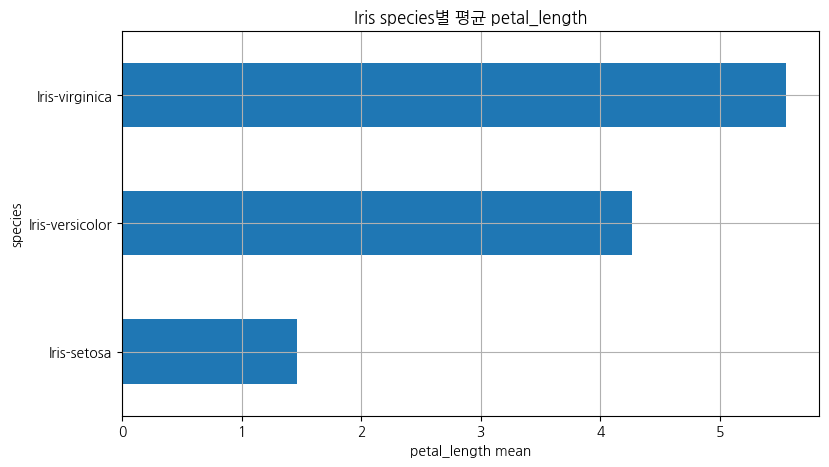

In [43]:
# 품종별 꽃잎 길이 평균 시각화
ax = iris_summary['petal_length_mean'].sort_values().plot(kind='barh')
ax.set_title('Iris species별 평균 petal_length')
ax.set_xlabel('petal_length mean')
plt.show()

## 16. 실제 데이터 기반 그룹 연산 2: Cancer 진단 유형별 요약

`type`별로 평균 반경, 면적, 질감 등 주요 특성을 비교합니다.

In [44]:
cancer_type_summary = cancer.groupby('type').agg(
    count=('mean radius', 'count'),
    mean_radius=('mean radius', 'mean'),
    mean_texture=('mean texture', 'mean'),
    mean_area=('mean area', 'mean'),
    worst_radius=('worst radius', 'mean'),
    worst_area=('worst area', 'mean'),
)
cancer_type_summary

,count,mean_radius,mean_texture,mean_area,worst_radius,worst_area
type,,,,,,
benign,357,12.147,17.915,462.790,13.380,558.899
malignant,212,17.463,21.605,978.376,21.135,"1,422.286"


In [45]:
# malignant와 benign의 평균 차이가 큰 feature 찾기
cancer_means = cancer.groupby('type').mean(numeric_only=True)
feature_diff = (cancer_means.loc['malignant'] - cancer_means.loc['benign']).abs().sort_values(ascending=False)
feature_diff.head(10)

worst area        863.387
mean area         515.586
worst perimeter    54.364
area error         51.537
mean perimeter     37.290
worst radius        7.755
worst texture       5.803
mean radius         5.316
mean texture        3.690
perimeter error     2.324
dtype: float64

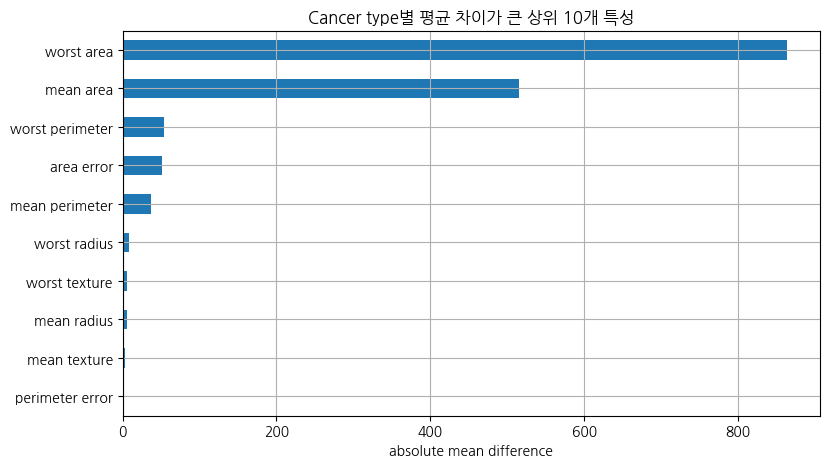

In [46]:
ax = feature_diff.head(10).sort_values().plot(kind='barh')
ax.set_title('Cancer type별 평균 차이가 큰 상위 10개 특성')
ax.set_xlabel('absolute mean difference')
plt.show()

## 17. 실제 데이터 기반 그룹 연산 3: CCTV 데이터 구간화 후 그룹 요약

연속형 변수를 구간화한 뒤 그룹별 요약을 수행하는 실무 패턴을 연습합니다.

In [47]:
cctv_work = cctv.copy()

# CCTV비율과 인구수 기준으로 구간 생성
cctv_work['인구구간'] = pd.qcut(cctv_work['인구수'], q=4, labels=['Q1_작음', 'Q2', 'Q3', 'Q4_큼'])
cctv_work['CCTV비율구간'] = pd.qcut(cctv_work['CCTV비율'], q=4, labels=['낮음', '보통', '높음', '매우높음'])

cctv_work[['구별', '인구수', '인구구간', 'CCTV비율', 'CCTV비율구간']].head()

,구별,인구수,인구구간,CCTV비율,CCTV비율구간
0,강남구,"570,500.000",Q4_큼,0.487,매우높음
1,강동구,"453,233.000",Q3,0.171,낮음
2,강북구,"330,192.000",Q1_작음,0.227,보통
3,강서구,"603,772.000",Q4_큼,0.146,낮음
4,관악구,"525,515.000",Q4_큼,0.285,보통


In [48]:
# 인구구간별 CCTV 및 고령자 비율 요약
cctv_work.groupby('인구구간', observed=False).agg(
    자치구수=('구별', 'count'),
    평균인구=('인구수', 'mean'),
    평균CCTV=('소계', 'mean'),
    평균CCTV비율=('CCTV비율', 'mean'),
    평균고령자비율=('고령자비율', 'mean')
)

,자치구수,평균인구,평균CCTV,평균CCTV비율,평균고령자비율
인구구간,,,,,
Q1_작음,7,"251,992.000","1,012.000",0.435,14.733
Q2,6,"382,576.667",842.500,0.219,13.304
Q3,6,"451,193.000","1,403.667",0.308,12.498
Q4_큼,6,"571,840.333","1,486.000",0.269,12.362


In [49]:
# 인구구간 x CCTV비율구간 빈도표
pd.crosstab(cctv_work['인구구간'], cctv_work['CCTV비율구간'])

CCTV비율구간,낮음,보통,높음,매우높음
인구구간,,,,
Q1_작음,0,2,2,3
Q2,3,2,1,0
Q3,2,0,2,2
Q4_큼,2,2,1,1


## 18. 실제 데이터 기반 그룹 연산 4: 주가 데이터의 시계열 그룹 연산

시계열 데이터에서는 날짜에서 연도, 월, 분기 같은 그룹 키를 추출해 집계합니다.

In [50]:
stock_long = stock.melt(id_vars='date', var_name='ticker', value_name='price')
stock_long['year'] = stock_long['date'].dt.year
stock_long['month'] = stock_long['date'].dt.month
stock_long['quarter'] = stock_long['date'].dt.to_period('Q').astype(str)

stock_long.head()

,date,ticker,price,year,month,quarter
0,2003-01-02,AAPL,7.400,2003,1,2003Q1
1,2003-01-03,AAPL,7.450,2003,1,2003Q1
2,2003-01-06,AAPL,7.450,2003,1,2003Q1
3,2003-01-07,AAPL,7.430,2003,1,2003Q1
4,2003-01-08,AAPL,7.280,2003,1,2003Q1


In [51]:
# 종목별 전체 통계
stock_long.groupby('ticker')['price'].agg(['count', 'mean', 'std', 'min', 'max'])

,count,mean,std,min,max
ticker,,,,,
AAPL,2214,125.516,107.395,6.560,422.000
MSFT,2214,23.945,3.255,14.330,34.070
SPX,2214,"1,183.773",180.983,676.530,"1,565.150"
XOM,2214,59.559,16.725,26.210,87.480


In [52]:
# 연도 x 종목별 평균 가격
year_ticker_mean = stock_long.groupby(['year', 'ticker'])['price'].mean().unstack('ticker')
year_ticker_mean.head()

ticker,AAPL,MSFT,SPX,XOM
year,,,,
2003,9.273,20.595,965.228,30.211
2004,17.764,21.850,"1,130.649",38.875
2005,46.676,23.072,"1,207.229",51.045
2006,70.811,23.759,"1,310.462",58.458
2007,128.274,27.904,"1,477.184",75.767


In [53]:
# 월말 가격 기준 수익률 계산
stock_monthly = stock.set_index('date').resample('M').last()
stock_monthly_return = stock_monthly.pct_change()
stock_monthly_return.head()

,AAPL,MSFT,XOM,SPX
date,,,,
2003-01-31,NaN,NaN,NaN,NaN
2003-02-28,0.046,0.002,0.003,-0.017
2003-03-31,-0.059,0.022,0.027,0.008
2003-04-30,0.006,0.056,0.007,0.081
2003-05-31,0.263,-0.038,0.041,0.051


In [54]:
# 종목별 월간 수익률 통계
stock_monthly_return.agg(['mean', 'std', 'min', 'max']).T.sort_values('mean', ascending=False)

,mean,std,min,max
AAPL,0.046,0.110,-0.330,0.352
XOM,0.011,0.053,-0.117,0.233
MSFT,0.006,0.067,-0.163,0.250
SPX,0.004,0.044,-0.169,0.094


In [55]:
# 연도별 평균 월간 수익률
monthly_return_long = stock_monthly_return.reset_index().melt(id_vars='date', var_name='ticker', value_name='monthly_return')
monthly_return_long['year'] = monthly_return_long['date'].dt.year
monthly_return_long.groupby(['year', 'ticker'])['monthly_return'].mean().unstack('ticker').head()

ticker,AAPL,MSFT,SPX,XOM
year,,,,
2003,0.041,0.015,0.025,0.020
2004,0.102,0.008,0.007,0.021
2005,0.075,0.000,0.003,0.012
2006,0.019,0.014,0.011,0.029
2007,0.076,0.019,0.003,0.019


## 19. 그룹 연산 결과 시각화

그룹 연산 결과는 보고서나 의사결정 자료로 활용되므로, 간단한 시각화까지 연결하는 것이 좋습니다.

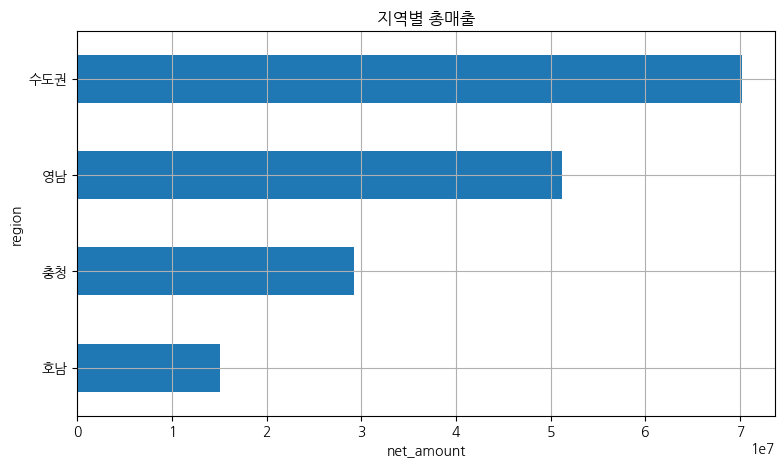

In [56]:
# 지역별 총매출
region_sales = sales_clean.groupby('region')['net_amount'].sum().sort_values()
ax = region_sales.plot(kind='barh')
ax.set_title('지역별 총매출')
ax.set_xlabel('net_amount')
plt.show()

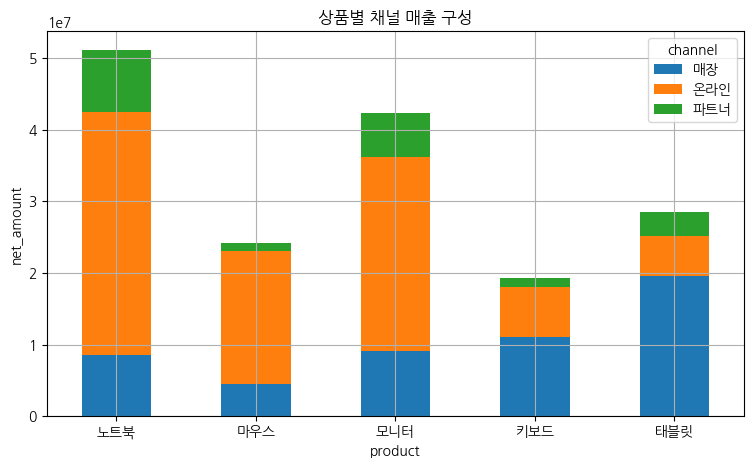

In [57]:
# 상품별 채널 매출 구성
product_channel = pd.pivot_table(
    sales_clean,
    values='net_amount',
    index='product',
    columns='channel',
    aggfunc='sum',
    fill_value=0
)
ax = product_channel.plot(kind='bar', stacked=True)
ax.set_title('상품별 채널 매출 구성')
ax.set_ylabel('net_amount')
plt.xticks(rotation=0)
plt.show()

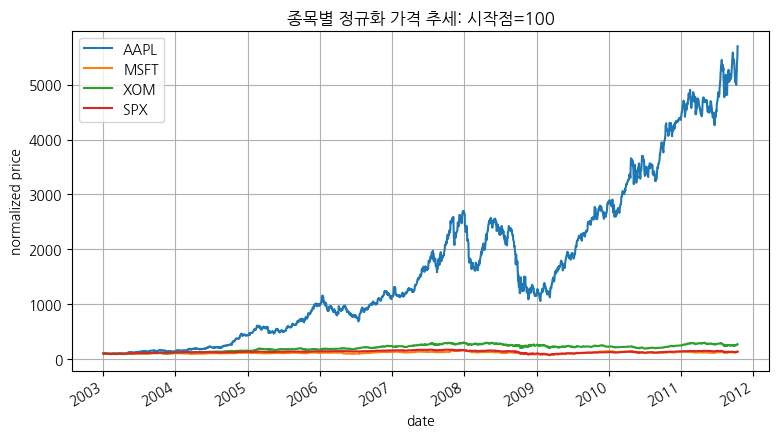

In [58]:
# 주가를 시작점 100으로 정규화해 추세 비교
normalized_stock = stock.set_index('date') / stock.set_index('date').iloc[0] * 100
ax = normalized_stock.plot()
ax.set_title('종목별 정규화 가격 추세: 시작점=100')
ax.set_ylabel('normalized price')
plt.show()

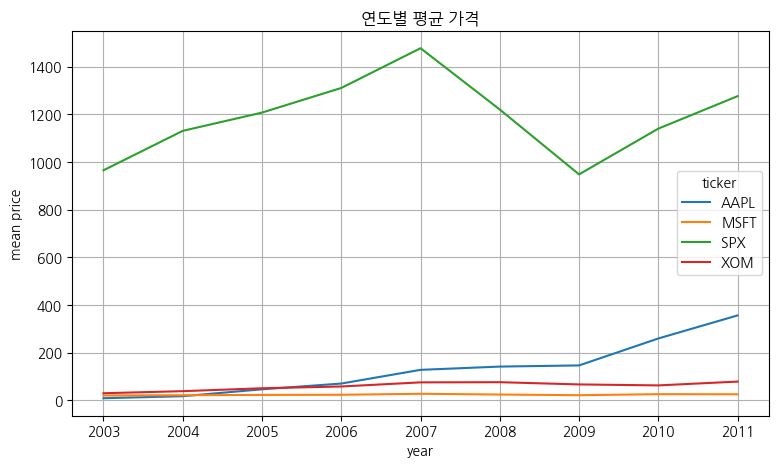

In [59]:
# 연도별 평균 가격 비교
ax = year_ticker_mean.plot()
ax.set_title('연도별 평균 가격')
ax.set_ylabel('mean price')
plt.show()

## 20. 실무 체크포인트: groupby 결과 검증

그룹 연산을 할 때는 아래를 확인합니다.

1. 그룹 키에 결측값이 있는가?
2. 그룹 수가 예상과 같은가?
3. 합계가 원본 합계와 일치하는가?
4. 중복 집계 또는 누락이 발생하지 않았는가?
5. 집계 단위가 분석 목적과 맞는가?

In [60]:
# 1. 그룹 키 결측 확인
sales_clean[['region', 'channel', 'product']].isna().sum()

region     0
channel    0
product    0
dtype: int64

In [61]:
# 2. 그룹 수 확인
sales_clean.groupby(['region', 'product']).ngroups

20

In [62]:
# 3. 집계 합계 검증
original_total = sales_clean['net_amount'].sum()
group_total = sales_clean.groupby('region')['net_amount'].sum().sum()

print('원본 합계:', original_total)
print('그룹 합계:', group_total)
print('차이:', original_total - group_total)
np.isclose(original_total, group_total)

원본 합계: 165551900.0
그룹 합계: 165551900.0
차이: 0.0


np.True_

In [63]:
# 4. 주문 ID 중복 확인
sales_clean['order_id'].duplicated().sum()

np.int64(0)

## 21. 종합 실습 문제

아래 문제는 먼저 직접 풀어보세요. 바로 아래에 풀이 예시가 있습니다.

### 문제 1
`sales_clean`에서 `region`, `channel`별 주문 수, 총매출, 평균 주문금액, 반품률을 계산하세요.

### 문제 2
`sales_clean`에서 상품별 총매출 상위 3개 상품을 구하세요.

### 문제 3
`iris`에서 품종별 `sepal_length`, `petal_length`의 평균과 표준편차를 구하세요.

### 문제 4
`cancer`에서 `type`별 `mean radius`, `mean area`, `worst area`의 평균을 구하고, malignant와 benign의 차이를 계산하세요.

### 문제 5
`stock` 데이터를 long format으로 변환한 뒤, 연도별·종목별 평균 가격 피벗 테이블을 만드세요.

### 문제 6
`sales_clean`에서 지역별 총매출 대비 각 주문의 매출 비중을 `transform`으로 계산하세요.

In [64]:
# 문제 1 풀이 예시
answer1 = sales_clean.groupby(['region', 'channel']).agg(
    주문수=('order_id', 'count'),
    총매출=('net_amount', 'sum'),
    평균주문금액=('net_amount', 'mean'),
    반품률=('is_returned', 'mean')
).sort_values('총매출', ascending=False)
answer1

주문수            총매출        평균주문금액   반품률
region channel                                        
수도권    온라인       41 52,467,700.000 1,279,700.000 0.098
영남     매장        15 21,712,750.000 1,447,516.667 0.133
       온라인       27 20,861,900.000   772,662.963 0.000
수도권    매장        25 16,543,150.000   661,726.000 0.080
충청     파트너        9 10,770,900.000 1,196,766.667 0.111
호남     온라인       18 10,141,400.000   563,411.111 0.111
충청     매장         8  9,883,500.000 1,235,437.500 0.000
영남     파트너        5  8,568,000.000 1,713,600.000 0.400
충청     온라인       10  8,517,300.000   851,730.000 0.100
호남     매장         6  4,666,500.000   777,750.000 0.000
수도권    파트너       10  1,135,500.000   113,550.000 0.200
호남     파트너        6    283,300.000    47,216.667 0.167

In [65]:
# 문제 2 풀이 예시
answer2 = sales_clean.groupby('product')['net_amount'].sum().sort_values(ascending=False).head(3)
answer2

product
노트북   51,164,500.000
모니터   42,352,000.000
태블릿   28,511,650.000
Name: net_amount, dtype: float64

In [66]:
# 문제 3 풀이 예시
answer3 = iris.groupby('species')[['sepal_length', 'petal_length']].agg(['mean', 'std'])
answer3

sepal_length       petal_length      
                        mean   std         mean   std
species                                              
Iris-setosa            5.006 0.352        1.464 0.174
Iris-versicolor        5.936 0.516        4.260 0.470
Iris-virginica         6.588 0.636        5.552 0.552

In [67]:
# 문제 4 풀이 예시
answer4_summary = cancer.groupby('type')[['mean radius', 'mean area', 'worst area']].mean()
answer4_diff = answer4_summary.loc['malignant'] - answer4_summary.loc['benign']

display(answer4_summary)
display(answer4_diff.to_frame('malignant_minus_benign'))

,mean radius,mean area,worst area
type,,,
benign,12.147,462.790,558.899
malignant,17.463,978.376,"1,422.286"


,malignant_minus_benign
mean radius,5.316
mean area,515.586
worst area,863.387


In [68]:
# 문제 5 풀이 예시
answer5 = stock.melt(id_vars='date', var_name='ticker', value_name='price')
answer5['year'] = answer5['date'].dt.year
answer5_pivot = answer5.groupby(['year', 'ticker'])['price'].mean().unstack('ticker')
answer5_pivot.head()

ticker,AAPL,MSFT,SPX,XOM
year,,,,
2003,9.273,20.595,965.228,30.211
2004,17.764,21.850,"1,130.649",38.875
2005,46.676,23.072,"1,207.229",51.045
2006,70.811,23.759,"1,310.462",58.458
2007,128.274,27.904,"1,477.184",75.767


In [69]:
# 문제 6 풀이 예시
answer6 = sales_clean.copy()
answer6['region_total_amount'] = answer6.groupby('region')['net_amount'].transform('sum')
answer6['order_share_in_region'] = answer6['net_amount'] / answer6['region_total_amount']
answer6[['order_id', 'region', 'net_amount', 'region_total_amount', 'order_share_in_region']].head()

,order_id,region,net_amount,region_total_amount,order_share_in_region
0,ORD-0002,영남,"27,500.000","51,142,650.000",0.001
1,ORD-0005,충청,"92,500.000","29,171,700.000",0.003
2,ORD-0011,수도권,"3,803,000.000","70,146,350.000",0.054
3,ORD-0012,충청,"228,000.000","29,171,700.000",0.008
4,ORD-0013,영남,"3,233,000.000","51,142,650.000",0.063


## 22. 마무리

이번 실습에서 다룬 핵심은 다음과 같습니다.

- `groupby`는 데이터를 나누고, 함수를 적용하고, 결과를 결합하는 구조입니다.
- 단순 집계는 `agg`, 원본 행 수를 유지해야 하면 `transform`, 복잡한 그룹별 로직은 `apply`, 그룹 자체를 걸러낼 때는 `filter`를 사용합니다.
- `pivot_table`과 `crosstab`은 보고서형 요약을 빠르게 만드는 데 유용합니다.
- 시계열 데이터는 날짜에서 연·월·분기 키를 만들거나 `resample`을 사용해 기간별로 요약할 수 있습니다.
- 그룹 연산 결과는 원본 합계와 비교하여 누락이나 중복 집계가 없는지 검증해야 합니다.